In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.image as mpimg
import numpy as np
from tqdm import tqdm

In [65]:
#examples
df = pd.read_csv('processeddata/joined_df_178.csv')
df['action_time'] = pd.to_datetime(df['action_time'])
df['Date']=pd.to_datetime(df['Date'])

# Marking guide

- Default Purple, or if not make sure it is the colour in the prompt
- Appropriate Title
- Axes
- Right font
- Right Colours

In [66]:
manjari_bold_path = 'font/Manjari-Bold.ttf'
manjari_regular_path = 'font/Manjari-Regular.ttf'
manjari_thin_path = 'font/Manjari-thin.ttf'

dark = "#3B3365"
medium = "#8F81DD"
light = "#BCADFF"
peach = "#FFEEDD"
blue = "#A7C7E7"
pink = "#FFB7C5"
green = "#B0E57C"
yellow = "#FFF2B2"
orange = "#FFD1BA"
mint = "#B5EAD7"
aqua = "#A1EAFB"


logo_img = mpimg.imread('Media/horizontal-logo.png')

# Load the custom font
manjari_bold = fm.FontProperties(fname=manjari_bold_path)
manjari_regular = fm.FontProperties(fname=manjari_regular_path)
manjari_thin = fm.FontProperties(fname=manjari_thin_path)

In [67]:
df[df['item']=='Paper Bag']['type'].unique()

array(['Miscellaneous'], dtype=object)

Text(0.5, 1.0, "Quantity of Ben's Film Sales")

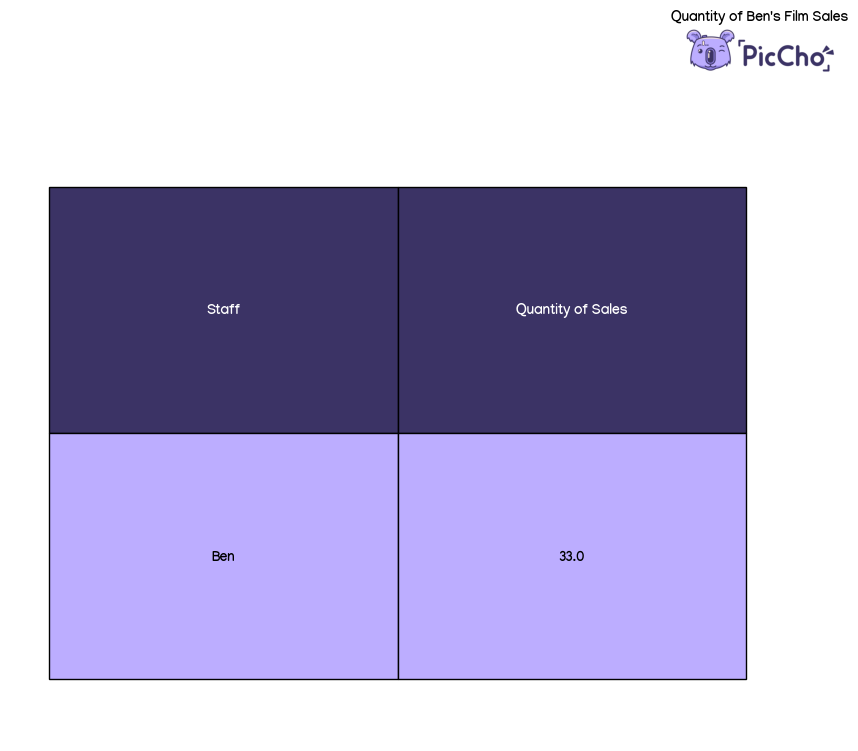

In [20]:
filtered_df = df[(df['worker'] == 'Ben') & (df['type'] == 'Photo')]
count_sales = filtered_df.groupby('worker')['count'].sum().reset_index()
count_sales.columns = ['Staff', 'Quantity of Sales']
plt.subplots(figsize=(10, 8))
plt.axis('off')
plt.axis('tight')
table = plt.table(cellText=count_sales.values, colLabels=count_sales.
    columns, cellLoc='center', bbox=[0.05, 0.1, 0.9, 0.8])
logo_ax = plt.axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off')
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='white', font=manjari_bold)
        cell.set_facecolor('#3B3365')
    else:
        cell.set_text_props(weight='bold', color='black', font=manjari_bold)
        cell.set_facecolor('#8F81DD') if i % 2 == 0 else cell.set_facecolor(
            '#BCADFF')
plt.title("Quantity of Ben's Film Sales", weight='bold', font_properties=
    manjari_bold)

In [25]:
filtered_df = df[(df['worker'] == 'Ben') & (df['type'] == 'Miscellaneous')]
count_sales = filtered_df.groupby('worker')['count'].sum().reset_index()
count_sales

,worker,count


In [68]:
df['band'].unique()

array([nan, 'Enhypen', 'Stray Kids', 'Seventeen', '(G)I-DLE', 'aespa',
       'NCT Dream', 'BTS', 'BTS V', 'BTS JungKook', 'ZEROBASEONE',
       'Ateez', 'Nayeon', 'Tomorrow X Together', 'New Jeans', 'Twice',
       'Le Sserafim', 'BTS Jimin', 'ITZY', 'IU', 'EXO'], dtype=object)

IndexError: index 0 is out of bounds for axis 0 with size 0

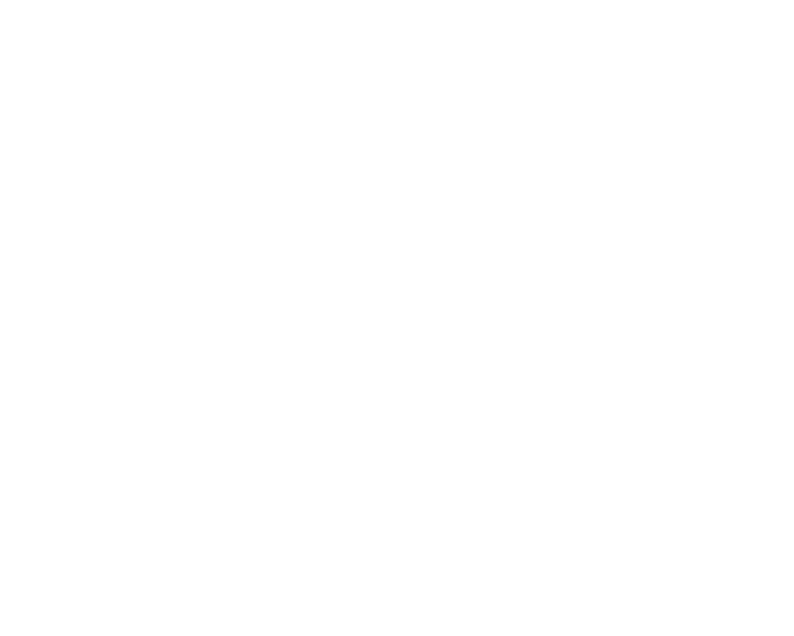

In [61]:
filtered_df = df[df['band']=='BTS']
count_sales = filtered_df.groupby('band')['count'].sum().reset_index()
count_sales.columns = ['#XAXIS#', '#YAXIS#']

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=count_sales.values, 
    colLabels=count_sales.columns, 
    cellLoc='center',
    bbox=[0.05, 0.1, 0.9, 0.8]
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor("#3B3365") 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor("#8F81DD") if i % 2 == 0 else cell.set_facecolor("#BCADFF")

ax.set_title('#TITLE#', weight='bold', font_properties=manjari_bold)

In [54]:
def sum_category(lol):
    # print(lol)
    type_list = lol['type']
    count_list = lol['count']
    return np.where(type_list=='Miscellaneous',count_list,0).sum()

filtered_df = df[df['worker']=='Ben']
filtered_df = filtered_df.groupby('worker').apply(sum_category).reset_index()
filtered_df.columns = ['lol','you']
filtered_df

,lol,you
0,Ben,0.0


In [6]:
total_sales_per_day = df.groupby('Date')['value'].sum().reset_index()
total_sales_per_day['Weekly Moving Average'] = total_sales_per_day['value'].rolling(window=7).mean()
total_sales_per_day

,Date,value,Weekly Moving Average
0,2024-06-10,523.60,NaN
1,2024-06-11,375.85,NaN
2,2024-06-12,770.60,NaN
3,2024-06-13,950.75,NaN
4,2024-06-14,914.65,NaN
...,...,...,...
72,2024-08-21,139.95,225.357143
73,2024-08-22,135.95,194.228571
74,2024-08-23,50.00,161.385714
75,2024-08-24,305.85,167.942857


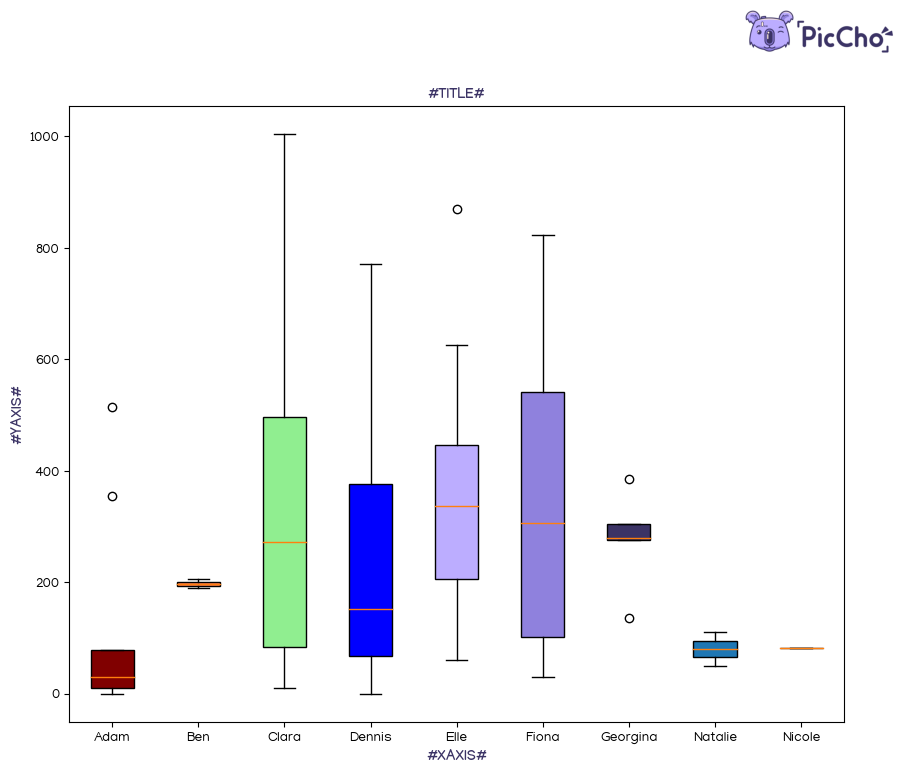

In [7]:
grouped_by_day = df.groupby(['worker','Date'])['value'].sum().reset_index()
staff_names = grouped_by_day['worker'].unique()
grouped_by_staff = [grouped_by_day[grouped_by_day['worker'] == staff]['value'].values for staff in staff_names]
fig, ax = plt.subplots(figsize=(10,8))
box = ax.boxplot(grouped_by_staff, labels=staff_names, patch_artist=True)
ax.set_title('#TITLE#', color="#3B3365", font_properties=manjari_bold)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
ax.set_xlabel('#XAXIS#', color="#3B3365", font_properties=manjari_bold)
ax.set_ylabel('#YAXIS#', color="#3B3365", font_properties=manjari_bold)
colors=["#800000", "#FF7F50", "#90EE90", "#0000FF", "#BCADFF", "#8F81DD", "#3B3365"]
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)

for patch, colour in zip(box['boxes'],colors):
    patch.set_facecolor(colour)

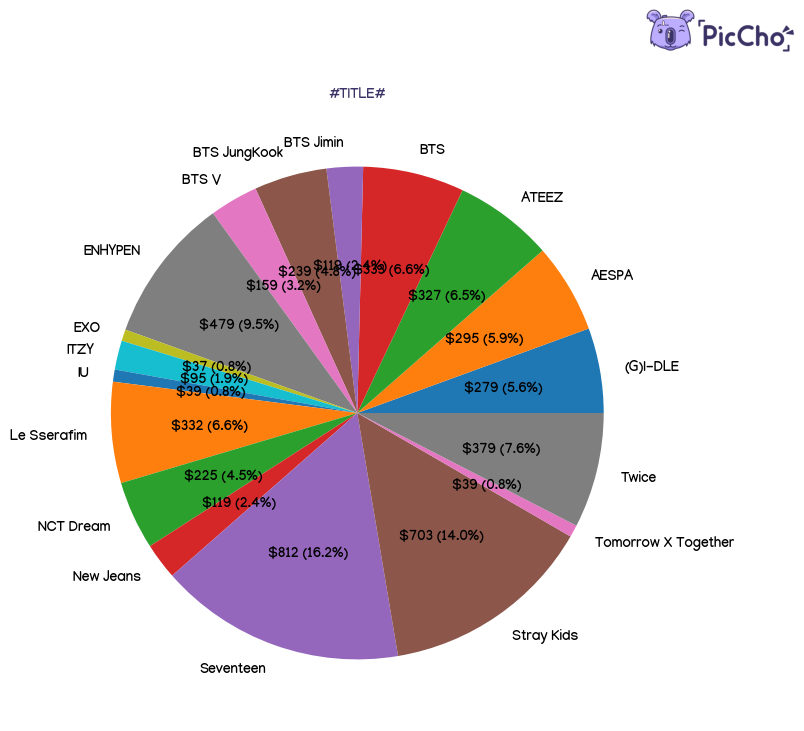

In [16]:
test = """def format_autopct(pct, allvalues):
    absolute = int(pct / 100. * sum(allvalues))
    return f"${absolute} ({pct:.1f}%)"

fig, ax = plt.subplots(figsize=(10,8))
physical_sales_df = df[(df['type']=='Album') & (~pd.isna(df['value']))]
physical_sales_per_product = physical_sales_df.groupby('band')['value'].sum().reset_index()
ax.pie(physical_sales_per_product['value'], labels=physical_sales_per_product['band'], autopct=lambda pct: format_autopct(pct, physical_sales_per_product['value']), textprops={'fontproperties': manjari_bold})
ax.set_title('#TITLE#', color="#3B3365", font_properties=manjari_bold)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
"""
exec(test)

(-0.5, 1616.5, 474.5, -0.5)

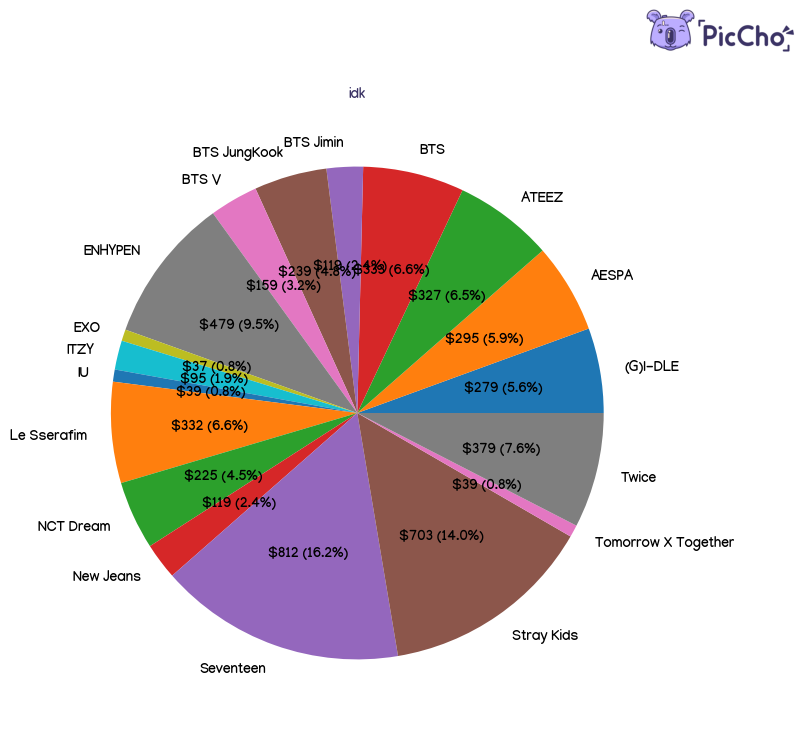

In [10]:
def format_autopct(pct, allvalues):
    absolute = int(pct / 100. * sum(allvalues))
    return f"${absolute} ({pct:.1f}%)"

fig, ax = plt.subplots(figsize=(10,8))
physical_sales_df = df[(df['type']=='Album') & (~pd.isna(df['value']))]
physical_sales_per_product = physical_sales_df.groupby('band')['value'].sum().reset_index()
ax.pie(physical_sales_per_product['value'], labels=physical_sales_per_product['band'], autopct=lambda pct: format_autopct(pct, physical_sales_per_product['value']), textprops={'fontproperties': manjari_bold})
ax.set_title('idk', color="#3B3365", font_properties=manjari_bold)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

In [23]:
album_sales = df[df['type']=='Album']
album_sales_summary = album_sales.groupby('item')['total'].sum().reset_index()
album_sales_summary.columns = ['Album', 'Total Sales ($)']
fig, ax = plt.subplots()
ax.bar(album_sales_summary['Album'],album_sales_summary['Total Sales ($)'],color=medium)
ax.set_xlabel('Album', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=90)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Sales in Copies per Album', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off')

category
Album            29.951733
Miscellaneous    17.646667
Photo             8.732143
Name: total, dtype: float64

In [9]:
df.columns

Index(['Date', 'value', 'count', 'id', 'item', 'worker', 'band', 'type',
       'photobooth', 'base', 'action_time', 'old_staff', 'Day'],
      dtype='object')

(-0.5, 1616.5, 474.5, -0.5)

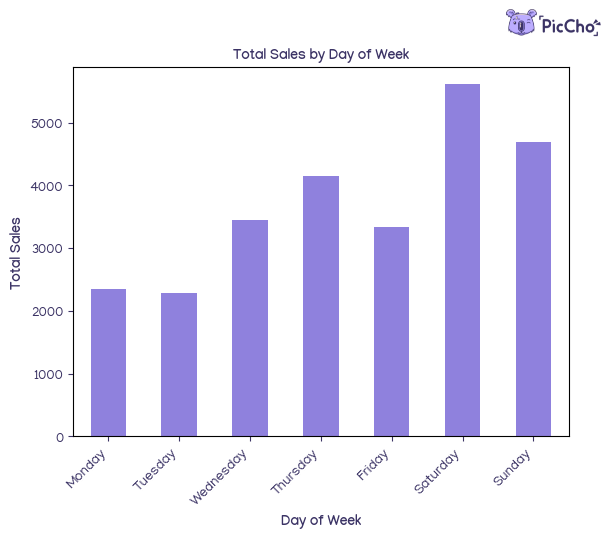

In [10]:
df['Day'] = df['action_time'].dt.day_name()
total_sales_per_day = df.groupby('Day')['value'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
total_sales_per_day.columns = ['Day of Week', 'Total Sales ($)']
fig, ax = plt.subplots()
total_sales_per_day.plot(kind='bar', color=medium, ax=ax)
ax.set_xlabel('Day of Week', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Sales by Day of Week', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

In [43]:
df.columns

Index(['Date', 'value', 'count', 'id', 'item', 'worker', 'band', 'type',
       'photobooth', 'base', 'action_time', 'old_staff', 'Day'],
      dtype='object')

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/895203568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  photo_df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')


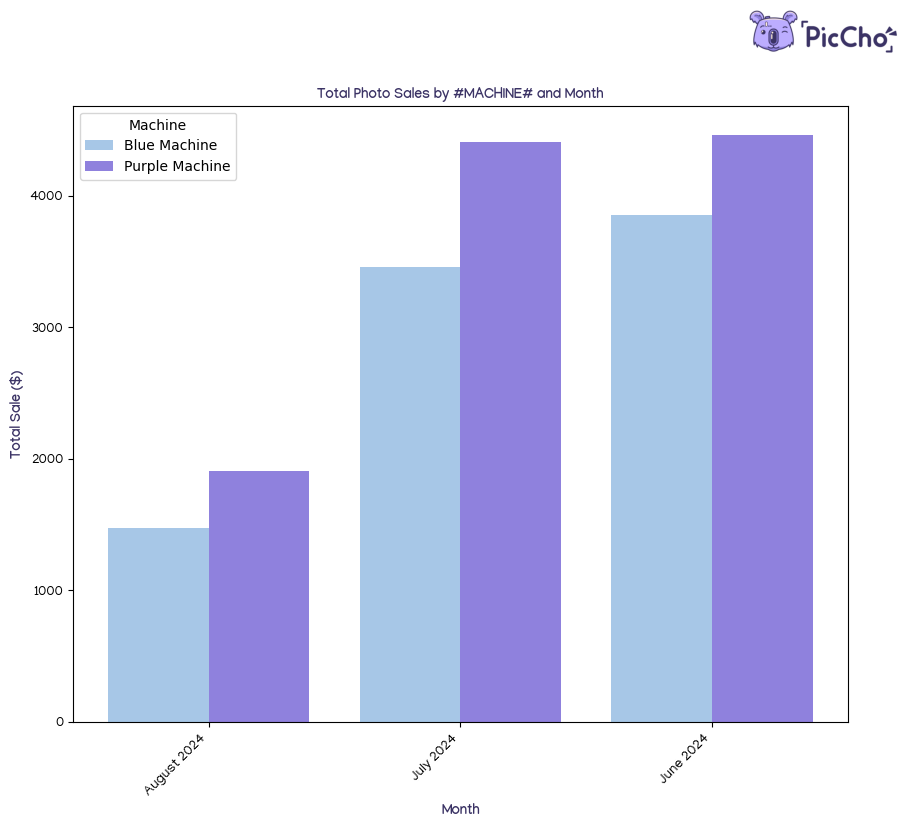

In [75]:
photo_df = df[df['type']=='Photo']
photo_df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
monthly_sales = photo_df.groupby(['Month', 'photobooth'])['value'].sum().reset_index()
monthly_sales['Month']=monthly_sales['Month'].dt.strftime('%B %Y')
pivot_sales = monthly_sales.pivot(index='Month', columns='photobooth', values='value').fillna(0)
months = pivot_sales.index.astype(str)
machines = pivot_sales.columns
num_machines = len(machines)
x = np.arange(len(months))
bar_width = 0.8 / num_machines  # Adjust the width based on the number of machines
fig, ax = plt.subplots(figsize=(10, 8))

for i, product in enumerate(machines):
    if i % 2 == 0:
        ax.bar(x + i * bar_width, pivot_sales[product], width=bar_width, label=product,color=blue)
    else:
        ax.bar(x + i * bar_width, pivot_sales[product], width=bar_width, label=product,color=medium)

ax.set_xlabel('Month', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sale ($)', color=dark, font_properties=manjari_bold)
ax.set_xticks(x + bar_width * (num_machines - 1) / 2, months)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Photo Sales by #MACHINE# and Month', color=dark, font_properties=manjari_bold)
ax.legend(title='Machine')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.savefig('test.png')

In [19]:
total_sales_per_day

Day
Monday       2342.35
Tuesday      2287.10
Wednesday    3454.95
Thursday     4146.65
Friday       3343.10
Saturday     5609.95
Sunday       4690.85
Name: value, dtype: float64

In [26]:
df.columns

Index(['Date', 'value', 'count', 'id', 'item', 'worker', 'band', 'type',
       'photobooth', 'base', 'action_time', 'old_staff', 'Day'],
      dtype='object')

In [35]:
df[df['worker']=='Jess'& df['type']=='Photo']

TypeError: Cannot perform 'rand_' with a dtyped [object] array and scalar of type [bool]

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/756995724.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/756995724.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


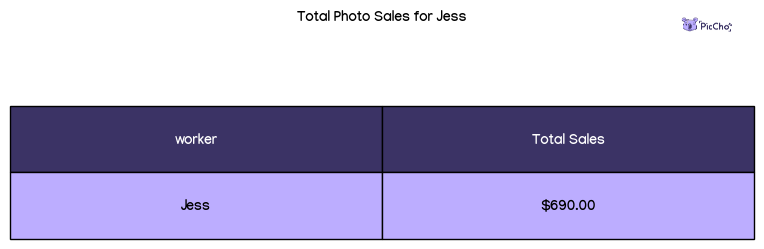

In [36]:
filtered_df = df[(df['worker']=='Jess') & (df['type']=='Photo')]
count_sales = filtered_df.groupby('worker')['value'].sum().reset_index()
count_sales.columns = ['worker', 'Total Sales']
count_sales['Total Sales'] = count_sales['Total Sales'].apply(lambda x: f'${x:,.2f}')

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=count_sales.values, 
    colLabels=count_sales.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Total Photo Sales for Jess", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()

In [41]:
df.columns

Index(['Date', 'value', 'count', 'id', 'item', 'worker', 'band', 'type',
       'photobooth', 'base', 'action_time', 'old_staff', 'Day'],
      dtype='object')

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/1522332683.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/1522332683.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


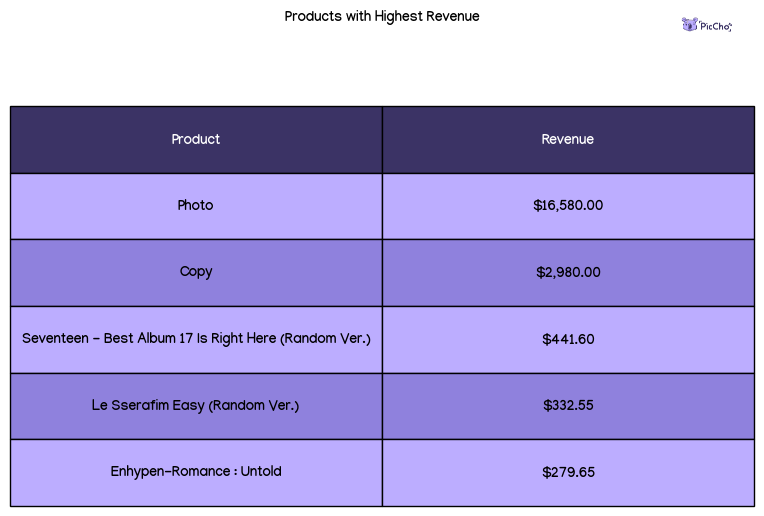

In [42]:
total_revenue = df.groupby('item')['value'].sum().reset_index()
total_revenue = total_revenue.sort_values(by='value',ascending=False)
total_revenue = total_revenue.iloc[:5]
total_revenue['value'] = total_revenue['value'].apply(lambda x: f'${x:,.2f}')
total_revenue.columns=['Product','Revenue']

fig, ax = plt.subplots(figsize=(8,1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=total_revenue.values, 
    colLabels=total_revenue.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title('Products with Highest Revenue', fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/1832267663.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_50637/1832267663.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


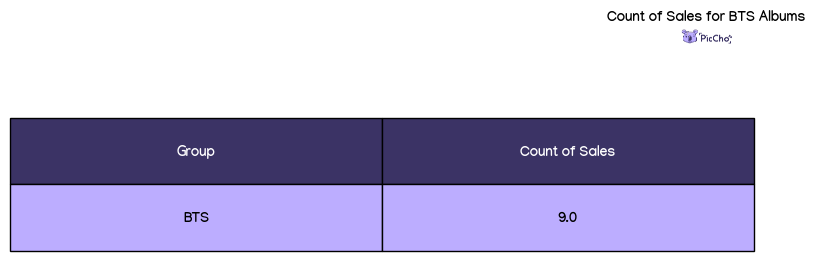

In [40]:
filtered_df = df[df['band'] == 'BTS']
count_sales = filtered_df.groupby('band')['count'].sum().reset_index()
count_sales.columns = ['Group', 'Count of Sales']
fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(cellText=count_sales.values, colLabels=count_sales.columns,
                     cellLoc='center')
logo_ax = plt.axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off')
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)
for (i, j), cell in table.get_celld().items():
        if i == 0:
                cell.set_text_props(weight='bold', color='white', font=manjari_bold)
                cell.set_facecolor(dark)
        else:
                cell.set_text_props(weight='bold', color='black', font=manjari_bold)
                cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)
                plt.title('Count of Sales for BTS Albums', fontsize=20, weight='bold',
                              font_properties=manjari_bold)
                plt.tight_layout()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_33305/1037194274.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_33305/1037194274.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


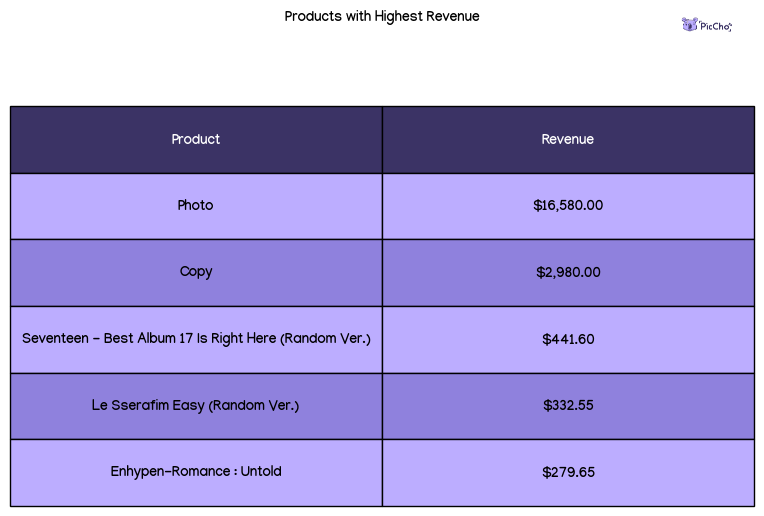

In [29]:
total_revenue = df.groupby('detail')['total'].sum().reset_index()
total_revenue = total_revenue.sort_values(by='total',ascending=False)
total_revenue = total_revenue.iloc[:5]
total_revenue['total'] = total_revenue['total'].apply(lambda x: f'${x:,.2f}')
total_revenue.columns=['Product','Revenue']

fig, ax = plt.subplots(figsize=(8,1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=total_revenue.values, 
    colLabels=total_revenue.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title('Products with Highest Revenue', fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show(block=False)

In [44]:
total_sales_per_day.reset_index()

,Day,total
0,Monday,2342.35
1,Tuesday,2287.10
2,Wednesday,3454.95
3,Thursday,4146.65
4,Friday,3343.10
5,Saturday,5609.95
6,Sunday,4690.85


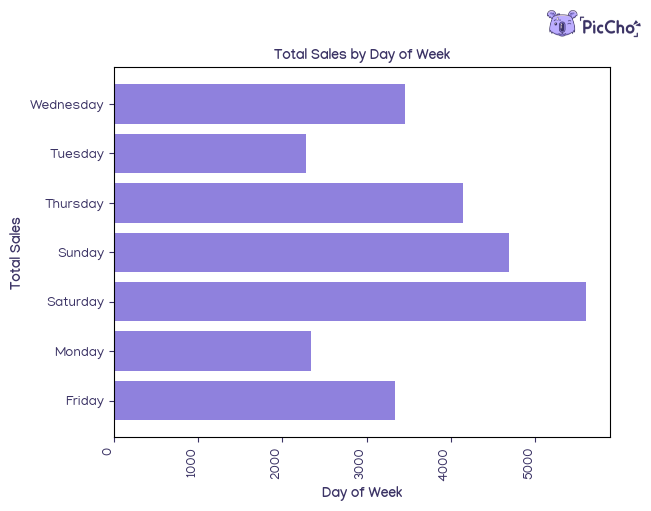

In [46]:
df['Day'] = df['action_time'].dt.day_name()
total_sales_per_day = df.groupby('Day')['total'].sum().reset_index()
fig, ax = plt.subplots()
ax.barh(total_sales_per_day['Day'],total_sales_per_day['total'],color=medium)
ax.set_xlabel('Day of Week', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=90)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Sales by Day of Week', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show(block=False)

In [13]:
transaction_total = df.groupby('order_id')['total'].sum().reset_index()
average_transaction = transaction_total['total'].mean()
average_transaction

10.53540309446254

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_30817/1411879493.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_30817/1411879493.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


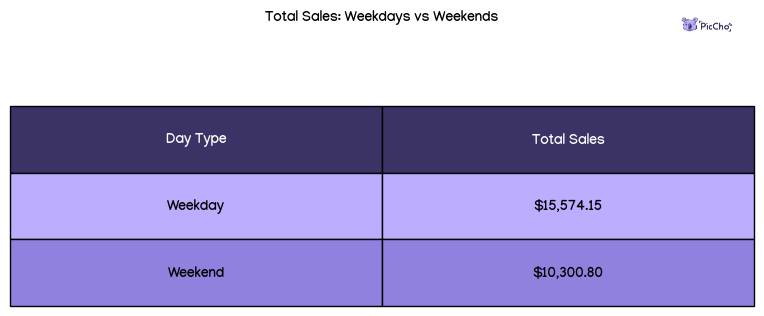

In [4]:
df['day_type'] = df['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
total_sales_per_type = df.groupby('day_type')['total'].sum().reset_index()
total_sales_per_type.columns = ['Day Type', 'Total Sales']
total_sales_per_type['Total Sales'] = total_sales_per_type['Total Sales'].apply(lambda x: f'${x:,.2f}')

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=total_sales_per_type.values, 
    colLabels=total_sales_per_type.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title('Total Sales: Weekdays vs Weekends', fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show(block=False)

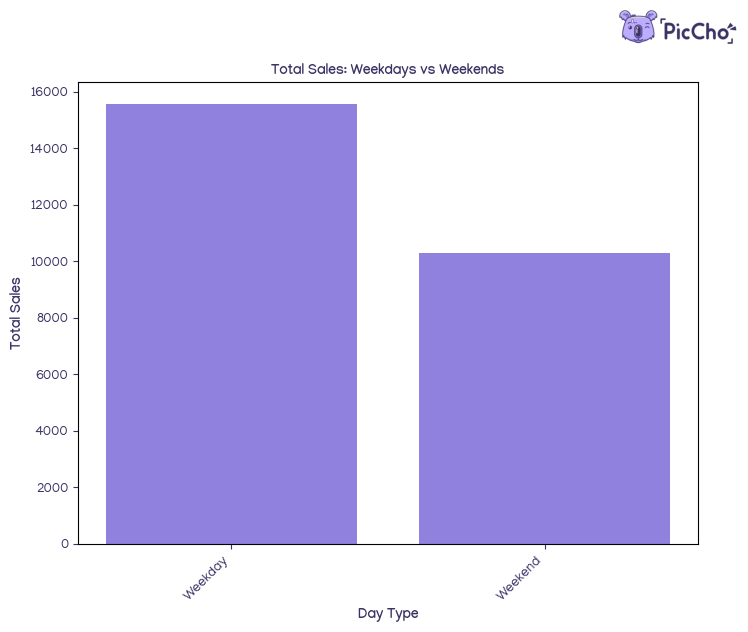

In [8]:
df['day_type'] = df['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
total_sales_per_type = df.groupby('day_type')['total'].sum().reset_index()
total_sales_per_type.columns = ['Day Type', 'Total Sales']
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(total_sales_per_type['Day Type'], total_sales_per_type['Total Sales'], color=medium)
ax.set_xlabel('Day Type', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales ($)', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Sales: Weekdays vs Weekends', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show(block=False)

In [5]:
filtered_df = df[df['type']=='BTS']
count_sales = filtered_df.groupby('type').size().reset_index()
count_sales.columns = ['Group', 'Count of Sales']
count_sales

,Group,Count of Sales
0,BTS,9


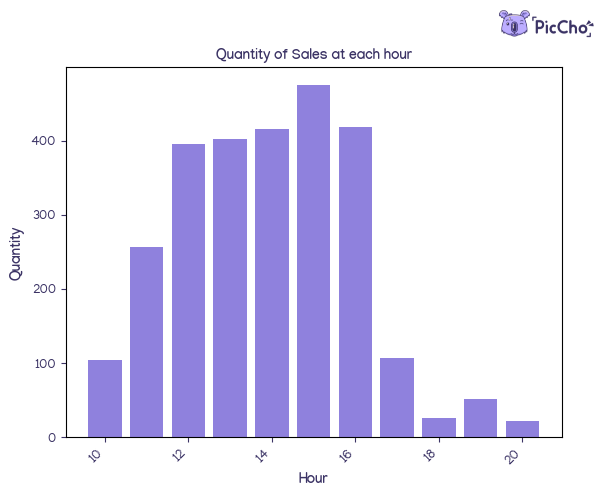

In [7]:
df['hour'] = df['action_time'].dt.hour
peak_hours = df.groupby('hour')['quantity'].sum().reset_index()
fig, ax = plt.subplots()
ax.bar(peak_hours['hour'], peak_hours['quantity'], color=medium)
ax.set_xlabel('Hour', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Quantity', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Quantity of Sales at each hour', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show(block=False)

In [12]:
zero_total

,staff,replaced,Date,action_time,product,type,quantity,base,total,hour
2,Amanda,NaN,2024-06-17,2024-06-17 10:24:14,Purple Machine,Photo,1.0,10.0,0.0,10.0
6,Amanda,NaN,2024-06-17,2024-06-17 12:52:49,Blue Machine,Photo,1.0,10.0,0.0,12.0
7,Amanda,NaN,2024-06-17,2024-06-17 13:03:23,Purple Machine,Photo,1.0,10.0,0.0,13.0
33,Amanda,NaN,2024-06-17,2024-06-17 16:53:58,Purple Machine,Photo,1.0,10.0,0.0,16.0
72,Amanda,NaN,2024-06-22,2024-06-22 14:33:42,Purple Machine,Photo,1.0,10.0,0.0,14.0
...,...,...,...,...,...,...,...,...,...,...
2490,Nicole,NaN,2024-08-25,2024-08-25 13:13:52,Blue Machine,Photo,1.0,10.0,0.0,13.0
2491,Nicole,NaN,2024-08-25,2024-08-25 13:18:56,Blue Machine,Photo,1.0,10.0,0.0,13.0
2492,Nicole,NaN,2024-08-25,2024-08-25 13:19:58,Purple Machine,Photo,1.0,10.0,0.0,13.0
2500,Nicole,NaN,2024-08-25,2024-08-25 15:27:55,Purple Machine,Photo,1.0,10.0,0.0,15.0


/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_23569/3825121044.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  photos_vs_copies['next_purchase'] = photos_vs_copies.groupby('product')['type'].shift(-1)
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_23569/3825121044.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  photos_vs_copies.loc[(photos_vs_copies['type'] == 'Photo') & (photos_vs_copies['next_purchase'] == 'Photo'), 'purchase_category'] = 'Only Photo'


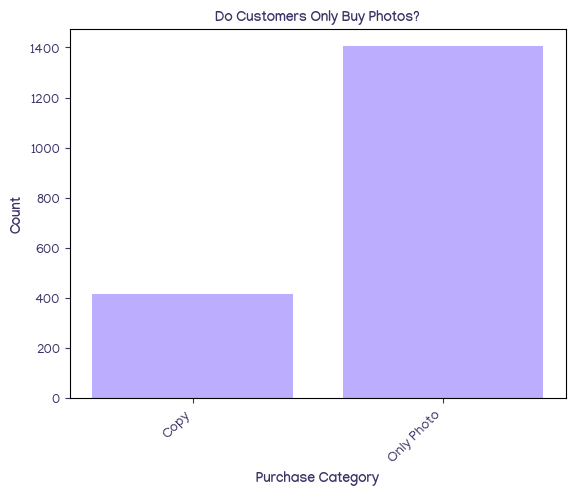

In [32]:
photos_vs_copies = df[df['product'].isin(['Blue Machine','Purple Machine'])]
photos_vs_copies['next_purchase'] = photos_vs_copies.groupby('product')['type'].shift(-1)
photos_vs_copies.loc[(photos_vs_copies['type'] == 'Photo') & (photos_vs_copies['next_purchase'] == 'Photo'), 'purchase_category'] = 'Only Photo'
photos_vs_copies.loc[(photos_vs_copies['type'] == 'Photo') & (photos_vs_copies['next_purchase'] == 'Copy/Print'), 'purchase_category'] = 'Copy'
photos_vs_copies_summary = photos_vs_copies.groupby('purchase_category').size().reset_index(name='count')
photos_vs_copies_summary.columns=['Purchase Category','Count']
fix, ax = plt.subplots()
ax.bar(photos_vs_copies_summary['Purchase Category'], photos_vs_copies_summary['Count'], color=light)
ax.set_xlabel('Purchase Category', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Count', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Do Customers Only Buy Photos?', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show(block=False)

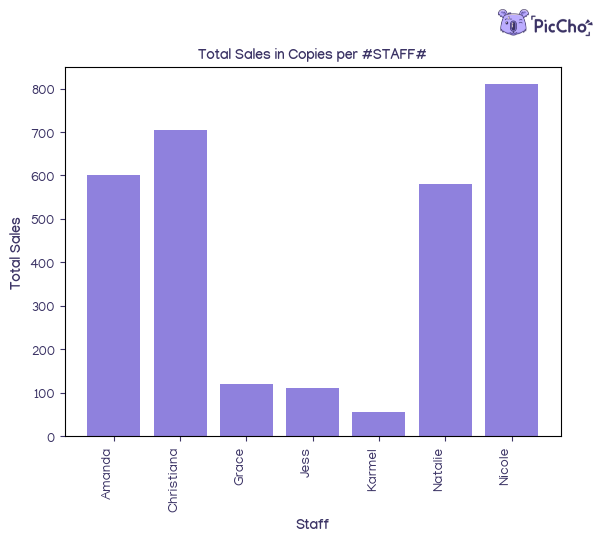

In [36]:
copy_sales = df[df['type']=='Copy/Print']
copy_sales_per_staff = copy_sales.groupby('staff')['total'].sum().reset_index()
copy_sales_per_staff.columns = ['Staff', 'Total Sales ($)']
fig, ax = plt.subplots()
ax.bar(copy_sales_per_staff['Staff'],copy_sales_per_staff['Total Sales ($)'],color=medium)
ax.set_xlabel('Staff', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=90)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Sales in Copies per #STAFF#', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show(block=False)

In [35]:
copy_sales_per_staff

,Staff,Total Sales ($)
0,Amanda,600.0
1,Christiana,705.0
2,Grace,120.0
3,Jess,110.0
4,Karmel,55.0
5,Natalie,580.0
6,Nicole,810.0


/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/1152389917.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  album_photo_comparison['Album/Photo'] = album_photo_comparison['type'].apply(lambda x: 'Photo' if x == 'Photo' else 'Album')


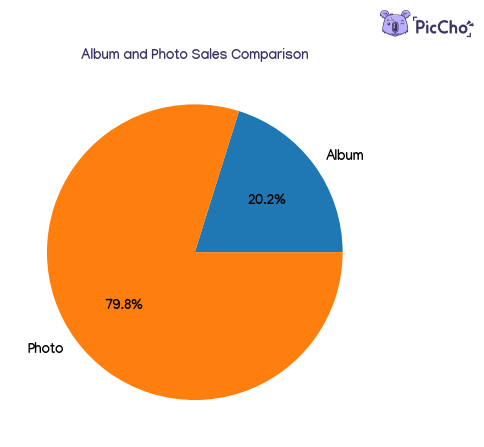

<Figure size 1200x1200 with 0 Axes>

In [273]:
#album sales vs photo sales

fig, ax = plt.subplots()
album_photo_comparison = df[(df['type'] != 'Unknown') & (~pd.isna(df['total']))]
album_photo_comparison['Album/Photo'] = album_photo_comparison['type'].apply(lambda x: 'Photo' if x == 'Photo' else 'Album')
album_photo_comparison_grouped = album_photo_comparison.groupby('Album/Photo')['total'].sum().reset_index()
plt.figure(figsize=(12,12))
ax.pie(album_photo_comparison_grouped['total'], labels=album_photo_comparison_grouped['Album/Photo'], autopct='%1.1f%%', textprops={'fontproperties': manjari_bold})
ax.set_title('Album and Photo Sales Comparison', color=dark, font_properties=manjari_bold)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.tight_layout()
plt.show()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2649151151.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2649151151.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


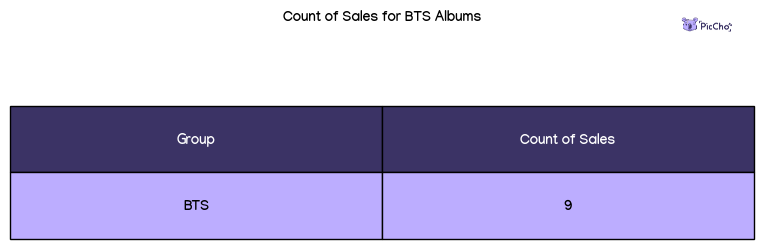

In [274]:
filtered_df = df[df['type']=='BTS']
count_sales = filtered_df.groupby('type').size().reset_index()
count_sales.columns = ['Group', 'Count of Sales']

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=count_sales.values, 
    colLabels=count_sales.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title('Count of Sales for BTS Albums', fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()

In [275]:
#give me a table of total albumns sold per month

albumn_data = df[(df['type']=='Physical') & (df['product'])]
albumn_data['action_time'] = pd.to_datetime(df['action_time'], errors='coerce')
monthly_sales = albumn_data.groupby(pd.Grouper(key='action_time', freq='M'))['quantity'].sum().reset_index()
monthly_sales.columns = ['Month','Total Albums']
monthly_sales

,Month,Total Albums
0,2024-06-30,0.0
1,2024-07-31,0.0
2,2024-08-31,0.0


In [276]:
#table of albums

albumn_data = df[(df['type']=='Physical') & (df['product'])]
albumn_data['action_time'] = pd.to_datetime(df['action_time'], errors='coerce')
monthly_sales = albumn_data.groupby(pd.Grouper(key='action_time', freq='M'))['quantity'].sum().reset_index()
monthly_sales.columns = ['Month','Total Albums']
monthly_sales

,Month,Total Albums
0,2024-06-30,0.0
1,2024-07-31,0.0
2,2024-08-31,0.0


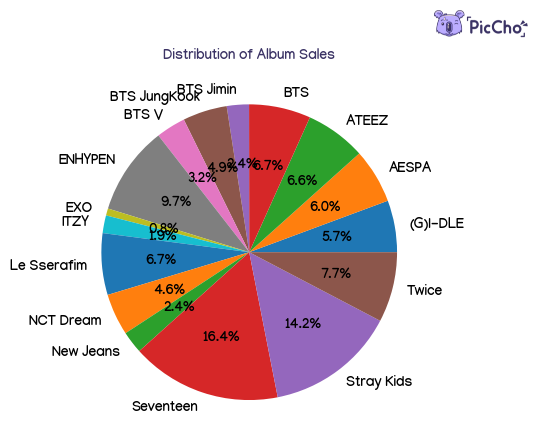

<Figure size 1200x1200 with 0 Axes>

In [277]:
#Show the distribution of sales per album

fig, ax = plt.subplots()
physical_sales_df = df[~df['type'].isin(['Photo','Unknown'])]
physical_sales_per_product = physical_sales_df.groupby('type')['total'].sum().reset_index()
plt.figure(figsize=(12,12))
ax.pie(physical_sales_per_product['total'], labels=physical_sales_per_product['type'], autopct='%1.1f%%', textprops={'fontproperties': manjari_bold})
ax.set_title('Distribution of Album Sales', color=dark, font_properties=manjari_bold)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.tight_layout()
plt.show()


In [278]:
#how many bts albums did we sell?
filtered_df = df[df['type']=='BTS']
len(filtered_df)

9

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2721648426.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2721648426.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


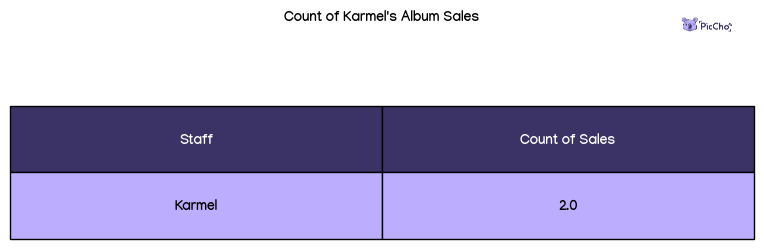

In [279]:
#how many albums have we sold with Karmel in the store

filtered_df = df[(df['staff']=='Karmel') & ~df['type'].isin(['Photo','Unknown'])]
count_sales = filtered_df.groupby('staff')['quantity'].sum().reset_index()
count_sales.columns = ['Staff', 'Count of Sales']

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=count_sales.values, 
    colLabels=count_sales.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Count of Karmel's Album Sales", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()


/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2472536758.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2472536758.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


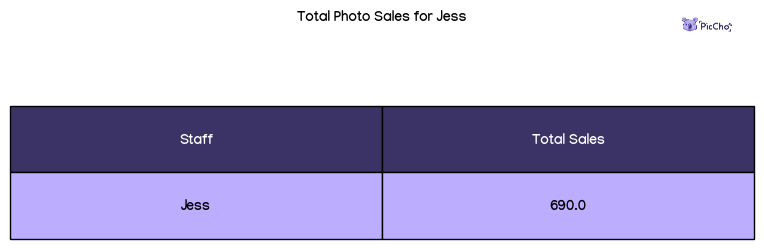

In [280]:
#total of photobooth sales on Jess' shifts? 

filtered_df = df[(df['staff']=='Jess') & df['type'].isin(['Photo'])]
count_sales = filtered_df.groupby('staff')['total'].sum().reset_index()
count_sales.columns = ['Staff', 'Total Sales']

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=count_sales.values, 
    colLabels=count_sales.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Total Photo Sales for Jess", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()


In [281]:
photo_df['Month']

0       2024-08
1       2024-08
2       2024-08
3       2024-08
4       2024-08
         ...   
2477    2024-08
2478    2024-08
2479    2024-08
2480    2024-08
2481    2024-08
Name: Month, Length: 2240, dtype: period[M]

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/1105518536.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  photo_df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/1105518536.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


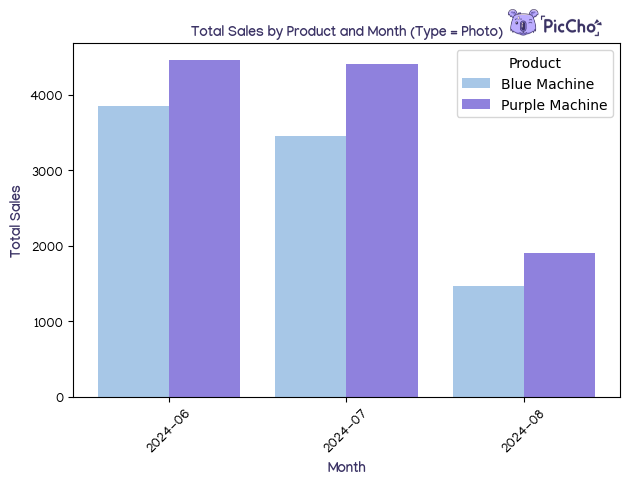

In [285]:
#total sales per month blue vs purple machine

photo_df = df[df['type']=='Photo']
photo_df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
monthly_sales = photo_df.groupby(['Month', 'product'])['total'].sum().reset_index()
pivot_sales = monthly_sales.pivot(index='Month', columns='product', values='total').fillna(0)
months = pivot_sales.index.astype(str)
products = pivot_sales.columns
num_products = len(products)
x = np.arange(len(months))
bar_width = 0.8 / num_products  # Adjust the width based on the number of products

# Create the plot
fig, ax = plt.subplots()

# Plot each product's sales data with an offset
for i, product in enumerate(products):
    if i % 2 == 0:
        ax.bar(x + i * bar_width, pivot_sales[product], width=bar_width, label=product,color=blue)
    else:
        ax.bar(x + i * bar_width, pivot_sales[product], width=bar_width, label=product,color=medium)

# Labeling
ax.set_xlabel('Month', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=90)
ax.set_title('Total Sales by Product and Month (Type = Photo)', color=dark, font_properties=manjari_bold)
plt.xticks(x + bar_width * (num_products - 1) / 2, months, rotation=45)
plt.legend(title='Product')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.tight_layout()
plt.show()



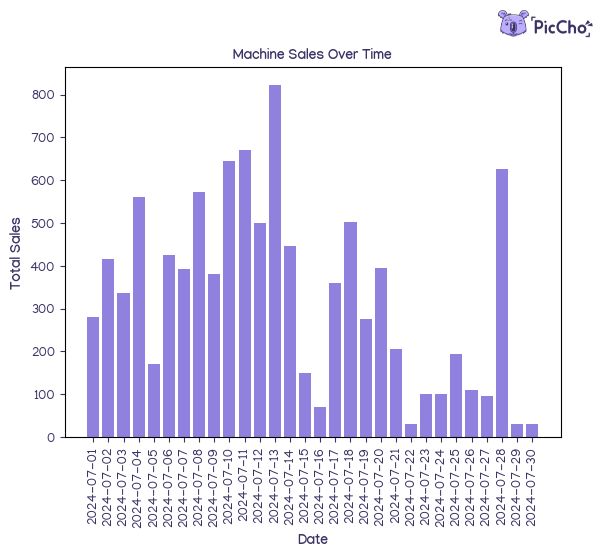

In [286]:
sales_data = df[(df['action_time']>='2024-07-01') & (df['action_time']<='2024-07-31')].groupby('Date')['total'].sum().reset_index()
fig, ax = plt.subplots()
ax.bar(sales_data['Date'], sales_data['total'], color=medium, linewidth=2)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=90)
# ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Machine Sales Over Time', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

In [ ]:
#pie chart of total sales per employee

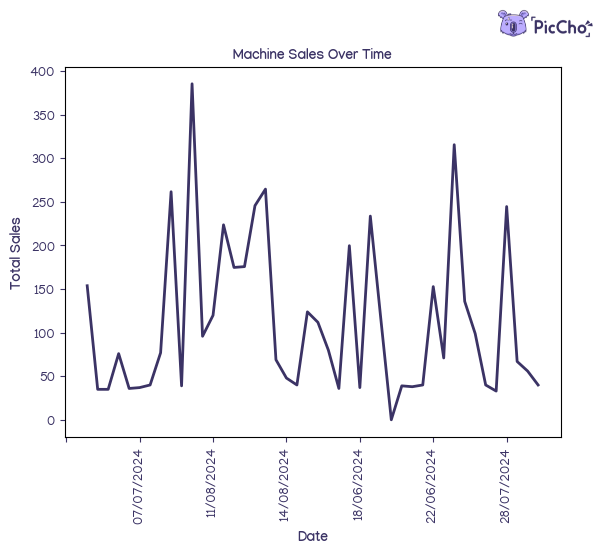

In [ ]:
# can you show me the total album sales over time

sales_data = df[~df['type'].isin(['Photo','Unknown'])]
sales_data = sales_data.groupby('Date')['total'].sum().reset_index()
fig, ax = plt.subplots()
ax.plot(sales_data['Date'], sales_data['total'], color=dark, linewidth=2)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Album Sales Over Time', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

In [ ]:
df.groupby('staff')['Date'].nunique().reset_index()

,staff,Date
0,Amanda,17
1,Christiana,19
2,Grace,5
3,Jess,7
4,Karmel,2
5,Natalie,16
6,Nicole,22


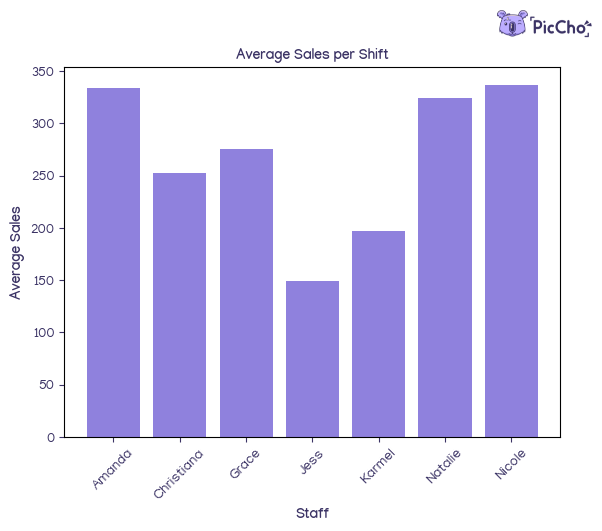

In [ ]:
#give me the average sales of each employee per shift
total_per_employee_day = df.groupby(['staff','Date'])['total'].sum().reset_index()
avg_per_employee = total_per_employee_day.groupby(['staff'])['total'].mean().reset_index()
avg_per_employee.columns=['Staff','Average']

fig, ax = plt.subplots()
ax.bar(avg_per_employee['Staff'], avg_per_employee['Average'], color=medium)
ax.set_xlabel('Staff', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Average Sales', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45)
ax.set_title('Average Sales per Shift', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/1844180559.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/1844180559.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


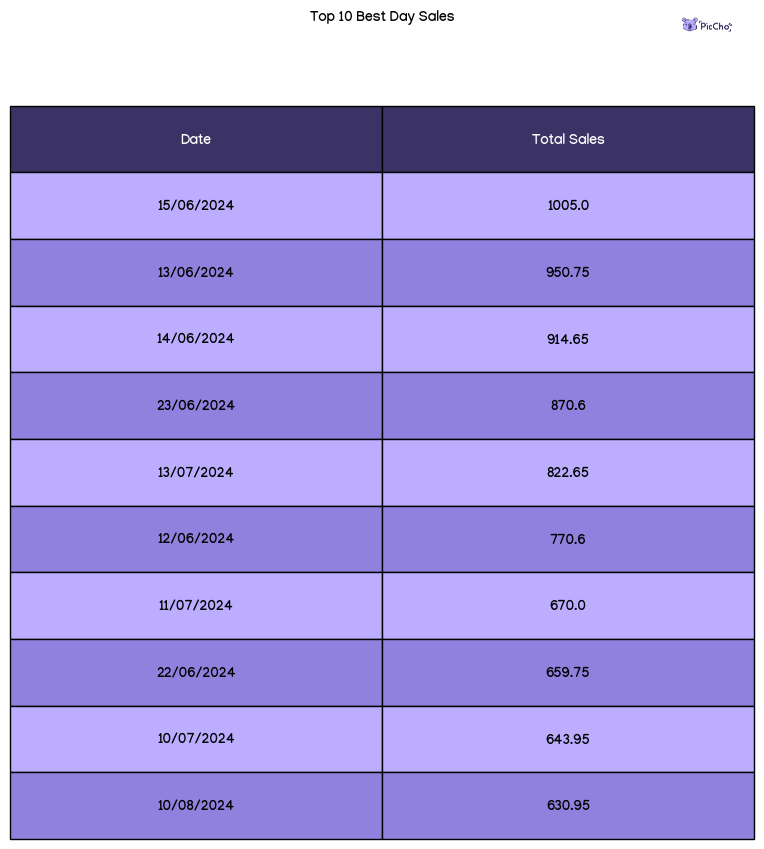

In [ ]:
#Order the days where sales were the highest

sales_by_date = df.groupby(['Date'])['total'].sum().reset_index()
top_10_sales_by_date = sales_by_date.sort_values(by='total', ascending=False).head(10)
top_10_sales_by_date.columns = ['Date','Total Sales']

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=top_10_sales_by_date.values, 
    colLabels=top_10_sales_by_date.columns, 
    cellLoc='center'
)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Top 10 Best Day Sales", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()


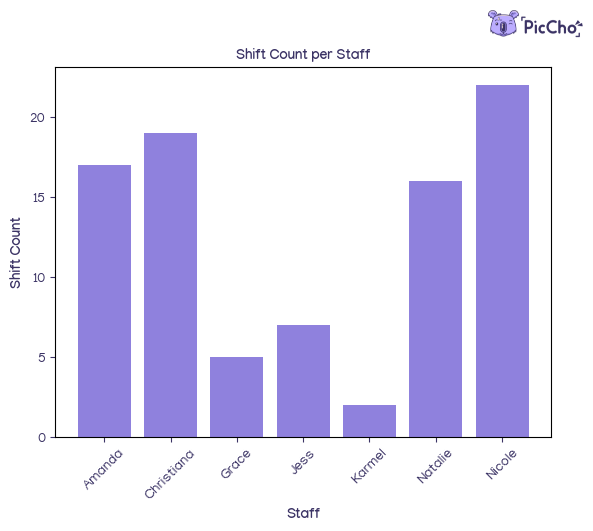

In [ ]:
# show me how many shifts each employee has taken

staff_shift_count = df.groupby('staff')['Date'].nunique().reset_index()
staff_shift_count.columns = ['Staff','Shift Count']

fig, ax = plt.subplots()
ax.bar(staff_shift_count['Staff'], staff_shift_count['Shift Count'], color=medium)
ax.set_xlabel('Staff', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Shift Count', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45)
ax.set_title('Shift Count per Staff', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/650898117.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/650898117.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


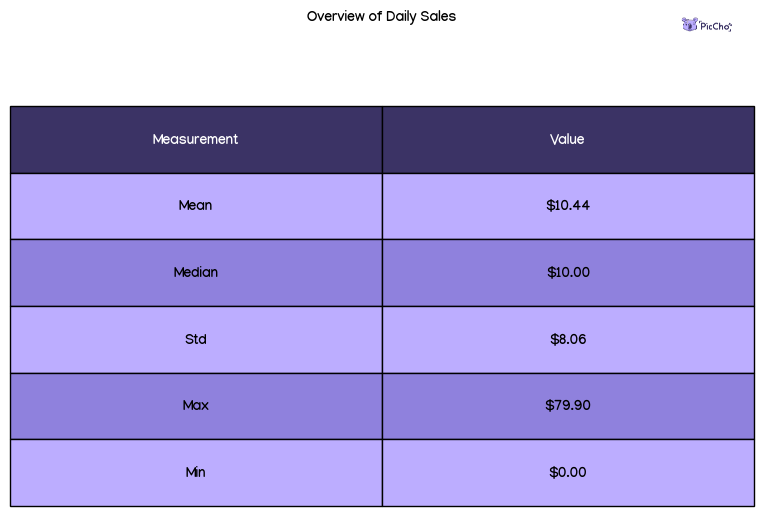

In [ ]:
daily_statistics = df.groupby('Date')['total'].sum().reset_index()
daily_statistics_agg = df['total'].agg(['mean','median','std','max','min']).round(2).reset_index()
daily_statistics_agg.columns = ['Measurement','Value']
daily_statistics_agg['Measurement']=daily_statistics_agg['Measurement'].str.title()
daily_statistics_agg['Value'] = daily_statistics_agg['Value'].apply(lambda x: f'${x:,.2f}')

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=daily_statistics_agg.values, 
    colLabels=daily_statistics_agg.columns, 
    cellLoc='center'
)

logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Overview of Daily Sales", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/1443307275.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


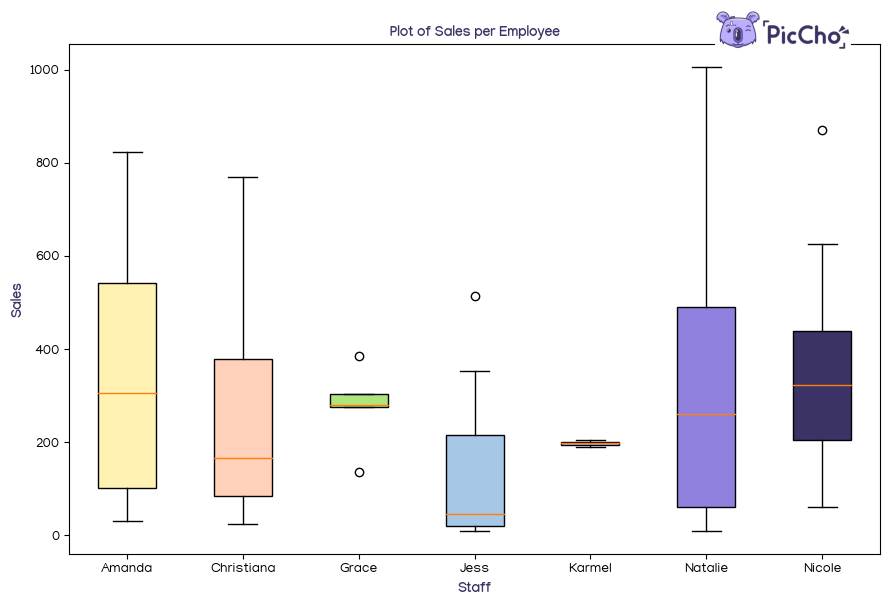

In [ ]:
#Generate a visual showing a boxplot each employee sale
grouped_by_day = df.groupby(['staff','Date'])['total'].sum().reset_index()
staff_names = grouped_by_day['staff'].unique()
grouped_by_staff = [grouped_by_day[grouped_by_day['staff'] == staff]['total'].values for staff in staff_names]
fig, ax = plt.subplots(figsize=(9,6))
box = ax.boxplot(grouped_by_staff, labels=staff_names, patch_artist=True)
ax.set_title('Plot of Sales per Employee', color=dark, font_properties=manjari_bold)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
ax.set_xlabel('Staff', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Sales', color=dark, font_properties=manjari_bold)
colors=[yellow, orange, green, blue, light, medium, dark]
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)

for patch, colour in zip(box['boxes'],colors):
    patch.set_facecolor(colour)

plt.tight_layout()
plt.show()



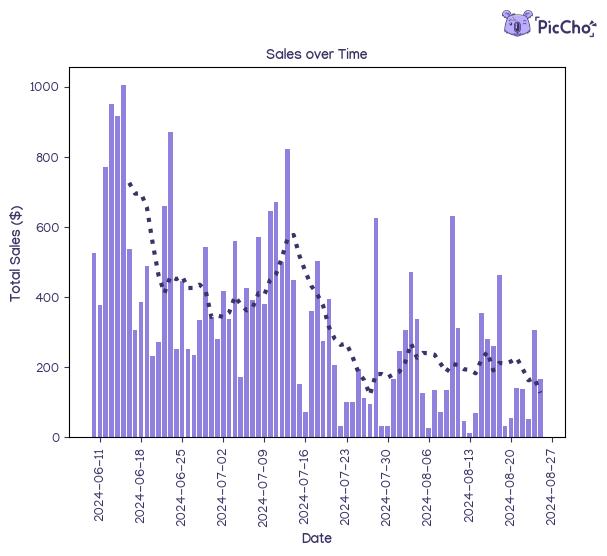

In [334]:
#get me the moving average of sales per week

total_sales_per_day = df.groupby('Date')['total'].sum().reset_index()
total_sales_per_day.set_index('Date', inplace=True)
total_sales_per_day['Weekly Moving Average'] = total_sales_per_day['total'].rolling(window=7).mean()
total_sales_per_day.columns=['Total Sales ($)', 'Weekly Moving Average ($)']

fig, ax = plt.subplots()
ax.bar(total_sales_per_day.index, total_sales_per_day['Total Sales ($)'], color=medium)
ax.plot(total_sales_per_day.index, total_sales_per_day['Weekly Moving Average ($)'], color=dark, linewidth=3, linestyle=':')
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales ($)', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=90)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Sales over Time', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2631878506.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/2631878506.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


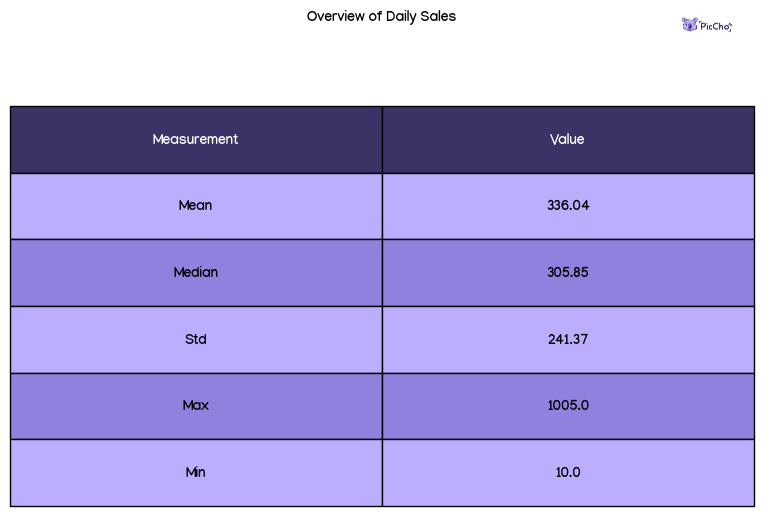

In [309]:
#can you give me a rundown of daily statistics
daily_statistics = df.groupby('Date')['total'].sum().reset_index()
daily_statistics_agg = daily_statistics['total'].agg(['mean','median','std','max','min']).round(2).reset_index()
daily_statistics_agg.columns = ['Measurement','Value']
daily_statistics_agg['Measurement']=daily_statistics_agg['Measurement'].str.title()

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=daily_statistics_agg.values, 
    colLabels=daily_statistics_agg.columns, 
    cellLoc='center'
)

logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Overview of Daily Sales", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()


/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/4083463615.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_sales['Day'] = pd.to_datetime(low_sales['Date']).dt.day_name()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/4083463615.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_76704/4083463615.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


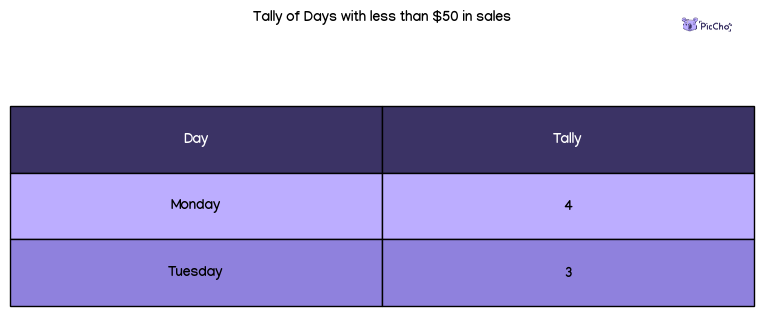

In [314]:
# tally the days where less than $50 of sales were made

total_sales_per_day = df.groupby('Date')['total'].sum().reset_index()
low_sales = total_sales_per_day[total_sales_per_day['total']<50]
low_sales['Day'] = pd.to_datetime(low_sales['Date']).dt.day_name()
low_sales_grouped = low_sales.groupby('Day')['Date'].nunique().reset_index()
low_sales_grouped.columns=['Day','Tally']

fig, ax = plt.subplots(figsize=(8, 1))
ax.axis('off')
ax.axis('tight')
table = ax.table(
    cellText=low_sales_grouped.values, 
    colLabels=low_sales_grouped.columns, 
    cellLoc='center'
)

logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 

table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.2, 4)

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_text_props(weight='bold', color='white',font=manjari_bold)
        cell.set_facecolor(dark) 
    else:
        cell.set_text_props(weight='bold', color='black',font=manjari_bold)
        cell.set_facecolor(medium) if i % 2 == 0 else cell.set_facecolor(light)

ax.set_title("Tally of Days with less than $50 in sales", fontsize=20, weight='bold', font_properties=manjari_bold)
plt.tight_layout()
plt.show()

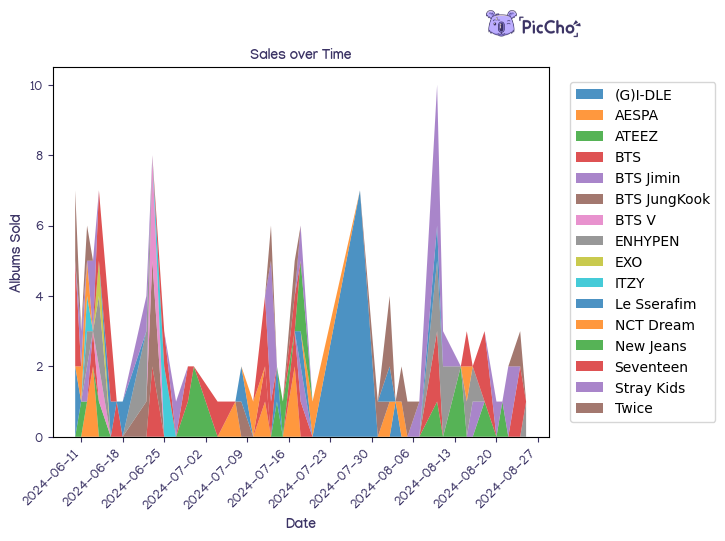

In [400]:
# area chart of albums sold over time
album_sales = df[~df['type'].isin(['Unknown','Photo'])]
total_album_sales = album_sales.groupby(['Date','type'])['quantity'].sum().reset_index()
pivot_df = total_album_sales.pivot(index='Date', columns='type', values='quantity').fillna(0)
x = pivot_df.index  
y = pivot_df.values.T 
fig, ax = plt.subplots()
ax.stackplot(x, y, labels=pivot_df.columns, alpha=0.8)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Albums Sold', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45,ha='right')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Sales over Time', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
ax.legend(loc='center right',bbox_to_anchor=(1.35, 0.5))
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

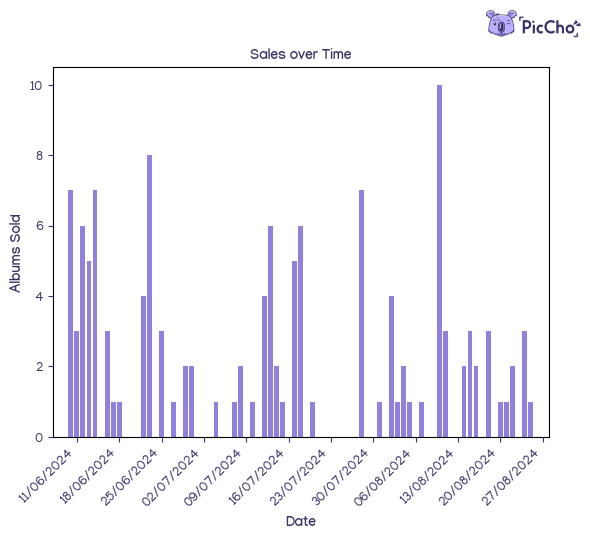

In [401]:
album_sales = df[~df['type'].isin(['Unknown','Photo'])]
total_album_sales = album_sales.groupby(['Date'])['quantity'].sum().reset_index()
total_album_sales['Date']=pd.to_datetime(total_album_sales['Date'])
fig, ax = plt.subplots()
ax.bar(total_album_sales['Date'], total_album_sales['quantity'], color=medium)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Albums Sold', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45,ha='right')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Sales over Time', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
ax.set_xlim(df['Date'].min()-pd.Timedelta(days=3),df['Date'].max()+pd.Timedelta(days=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y')) 
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

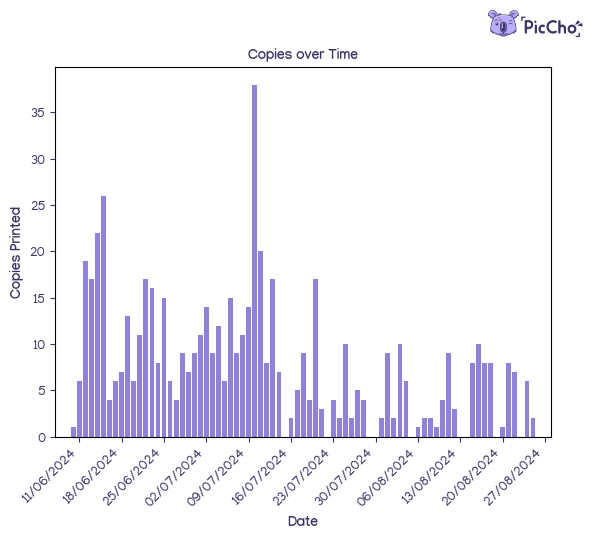

In [14]:
#how many copies are printed out over time

copy_sales = df[(df['type']=='Photo') & (df['base']==5)]
total_copy_sales = copy_sales.groupby(['Date'])['quantity'].sum().reset_index()
total_copy_sales['Date']=pd.to_datetime(total_copy_sales['Date'])
fig, ax = plt.subplots()
ax.bar(total_copy_sales['Date'], total_copy_sales['quantity'], color=medium)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Copies Printed', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45,ha='right')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Copies over Time', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
ax.set_xlim(df['Date'].min()-pd.Timedelta(days=3),df['Date'].max()+pd.Timedelta(days=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y')) 
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

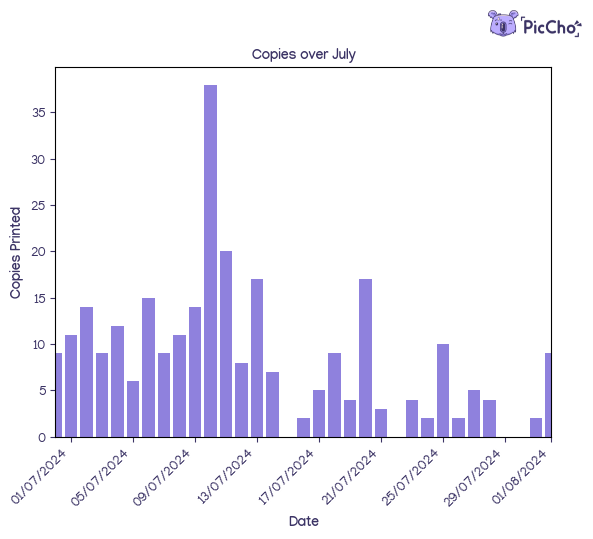

In [20]:
#how many copies were printed over july

copy_sales = df[(df['type']=='Photo') & (df['base']==5)]
total_copy_sales = copy_sales.groupby(['Date'])['quantity'].sum().reset_index()
fig, ax = plt.subplots()
ax.bar(total_copy_sales['Date'], total_copy_sales['quantity'], color=medium)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Copies Printed', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45,ha='right')
ax.set_title('Copies over July', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
ax.set_xlim(pd.to_datetime('2024-07-01')-pd.Timedelta(days=1), pd.to_datetime('2024-07-31')+pd.Timedelta(days=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y')) 
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

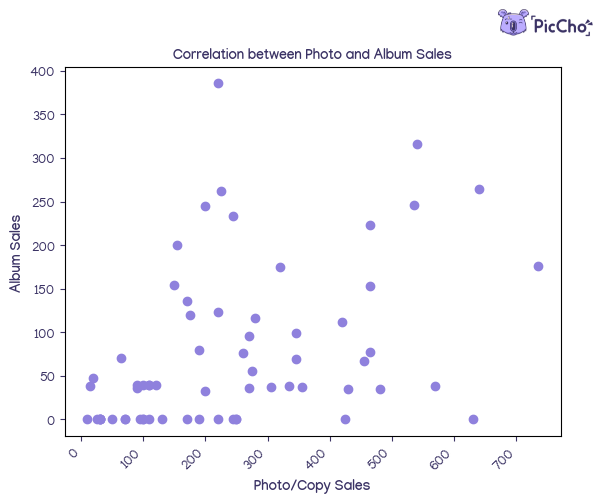

In [29]:
# can you show me if album sales are correlated with Photobooth sales?
photos_df = df[df['type'].isin(['Photo','Copy/Print'])]
albums_df = df[~df['type'].isin(['Photo','Copy/Print','Unknown'])]
photo_sales = photos_df.groupby('Date')['total'].sum().reset_index(name='photo_sales')
album_sales = albums_df.groupby('Date')['total'].sum().reset_index(name='album_sales')
merged_sales = pd.merge(photo_sales, album_sales, on='Date', how='inner')

fig, ax = plt.subplots()
ax.scatter(merged_sales['photo_sales'], merged_sales['album_sales'], color=medium)
ax.set_xlabel('Photo/Copy Sales', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Album Sales', color=dark, font_properties=manjari_bold)
plt.xticks(rotation=45,ha='right')
ax.set_title('Correlation between Photo and Album Sales', color=dark, font_properties=manjari_bold)
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show()

In [37]:
df[df['type']=='Copy/Print']

,staff,replaced,Date,action_time,product,type,quantity,base,total


/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_90850/2784813031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  photo_df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
/var/folders/9z/c7pg3d6d6_v_knn1lxf7vglc0000gn/T/ipykernel_90850/2784813031.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


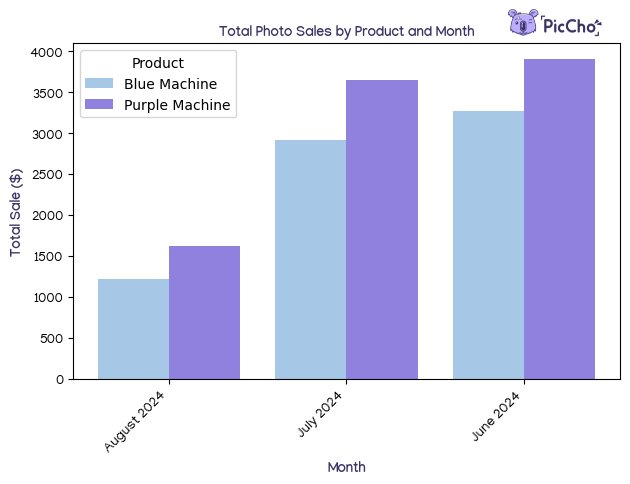

In [53]:
photo_df = df[df['type']=='Photo']
photo_df['Month'] = pd.to_datetime(df['Date']).dt.to_period('M')
monthly_sales = photo_df.groupby(['Month', 'product'])['total'].sum().reset_index()
monthly_sales['Month']=monthly_sales['Month'].dt.strftime('%B %Y')
pivot_sales = monthly_sales.pivot(index='Month', columns='product', values='total').fillna(0)
months = pivot_sales.index.astype(str)
products = pivot_sales.columns
num_products = len(products)
x = np.arange(len(months))
bar_width = 0.8 / num_products  # Adjust the width based on the number of products
fig, ax = plt.subplots()

for i, product in enumerate(products):
    if i % 2 == 0:
        ax.bar(x + i * bar_width, pivot_sales[product], width=bar_width, label=product,color=blue)
    else:
        ax.bar(x + i * bar_width, pivot_sales[product], width=bar_width, label=product,color=medium)

ax.set_xlabel('Month', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sale ($)', color=dark, font_properties=manjari_bold)
ax.set_xticks(x + bar_width * (num_products - 1) / 2, months)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.set_title('Total Photo Sales by Product and Month', color=dark, font_properties=manjari_bold)
ax.legend(title='Product')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.tight_layout()
plt.show(block=False)

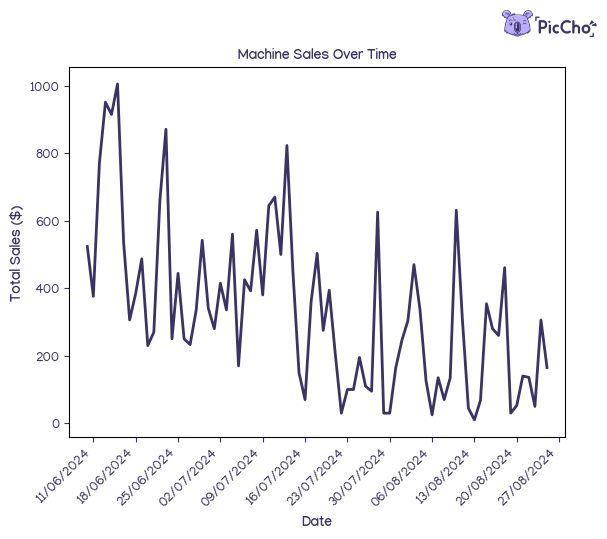

In [54]:
sales_data = df.groupby('Date')['total'].sum().reset_index()
fig, ax = plt.subplots()
ax.plot(sales_data['Date'], sales_data['total'], color=dark, linewidth=2)
ax.set_xlabel('Date', color=dark, font_properties=manjari_bold)
ax.set_ylabel('Total Sales ($)', color=dark, font_properties=manjari_bold)
ax.tick_params(axis='x', labelrotation=45)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.set_title('Machine Sales Over Time', color=dark, font_properties=manjari_bold)
ax.set_xlim(df['Date'].min() - pd.Timedelta(days=3), df['Date'].max() + pd.Timedelta(days=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y')) 
ax.tick_params(colors=dark)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(manjari_regular)
logo_ax = fig.add_axes([0.8, 0.85, 0.15, 0.15], anchor='NE', zorder=1)
logo_ax.imshow(logo_img)
logo_ax.axis('off') 
plt.show(block=False)

In [ ]:
#evaluators

def check_axes(input, output):
    return None

def check_title(input_data, ax):
    input_title = input_data['title']
    output_title = ax.get_title()
    
    if input_title == output_title:
        return True
    else:
        return False

def check_font(output):
    if "label.set_fontproperties(manjari" in output.replace(" ",""):
        return True
    return False